## 합성곱 신경망
- 이미지 처리에 탁월한 성능을 보낸다.
- 다층 퍼셉트론은 몇가지 픽셀만 값이 달라져도 예측에 더 민감하게 영향을 받음
- 이미지를 1차원으로 변환하고 다층 퍼셉트론의 입력층으로 사용하면 공간적인 구조(spatial structure)가 유실됨.
- 합성곱 신경망은 이미지의 **공간적인 구조 정보를 보존**하면서 학습시킬 수 있다.

### 채널
- 이미지는 높이, 너비, 채널 이라는 3차원 텐서이다.
- 높이: 세로 방향 픽셀 수
- 너비: 가로 방향 픽셀 수
- 채널: 색 성분
    - 흑백 이미지는 채널 수가 1개로 각 픽셀은 0부터 255사이 값을 가짐.
    - 컬러 이미지는 채널 수가 3개(R, G, B)
        - 높이, 너비 각각 100인 컬러 이미지는 (100, 100, 3) 크기의 텐서로 표현됨
- 채널은 깊이(depth) 라고도 한다.


## 합성곱 연산(Convolution operation)
- 합성곱층은 합성곱 연산을 통해 이미지의 특징을 추출하는 역할은 한다.
- **커널**(Kernal) 혹은 **필터**(filter)라 불리는 $n \times n$ 크기의 행렬로 $height \times width$ 크기의 이미지를 처음부터 끝까지 곂치며 훑어 곂치는 부분의 원소의 값을 곱하여 더한 값을 출력으로 내놓는다.
- 커널은 일반적으로 $3 \times 3$ 또는 $5 \times 5$ 크기를 사용한다.
- **특성 맵**(Feature Map): 입력 이미지와 커널을 사용하여 합성곱 연산을 통해 나온 결과  

---
- 합성곱 연산을 수행하면 특성맵은 입력보다 크기가 작아짐.
- 합성곱 층이 누적되면 특성 맵의 크기가 점점 작아지게 된다.
- 패딩을 사용하여(주로 제로 패딩) 입력 이미지의 가장자리에 픽셀을 추가하여 특성 맵의 크기를 유지할 수 있다.

## 합성곱 신경망
- **가중치**: 커널 행렬의 원소들.
    - 다층 퍼셉트론을 사용할 때보다 훨씬 적은 수의 가중치를 사용 + 공간적 구조 정보 보존
- **편향**: 커널이 적용된 모든 원소에 더해짐.(특성 맵의 모든 원소에 대해 동일한 편향이 더해짐. 가중치와 달리 편향은 단 하나.)

### 특성 맵의 크기
$$
\begin{align*}
O_{height} &= \left\lfloor \frac{\text{입력 이미지의 높이} - \text{커널의 높이} + 2 \times \text{패딩}}{\text{스트라이드}} + 1 \right\rfloor \\
O_{width} &= \left\lfloor \frac{\text{입력 이미지의 너비} - \text{커널의 너비} + 2 \times \text{패딩}}{\text{스트라이드}} + 1 \right\rfloor
\end{align*}
$$

### 다수의 채널
- 다수의 채널을 가진 이미지를 합성곱 처리하기 위해서는 각각의 채널에 대응되는 커널이 있어야 한다.
- (특성 맵의 개수) = (커널의 개수)
- 이후 특성 맵들을 합쳐서 최종 특성 맵을 얻는다.
- <img src="img/zs.png" width="600"/>
- <img src="img/zt.png" width="600"/>
- 이미지 채널과 커널 수는 같다.
- <img src="img/zu.png" width="600"/>
- 다수의 커널 $C_0$를 사용할 경우


## 풀링(Pooling)
- 일반적으로 합성곱 층(합성곱 연산 + 활성화 함수) 다음에 풀링 층을 추가한다.
- 최대 풀링(max pooling), 평균 풀링(average pooling) 등이 사용된다.
- 커널과 겹치는 영역 안에서 최대값/평균 을 추출하는 방식으로 다운샘플링 한다.
- 커널과 스트라이트 개념은 합성곱과 같으나, 학습할 가중치가 없고 연산 후 채널 수가 변하지 않는다.
$$\begin{align*}
\begin{bmatrix}\color{red}1 & \color{red}2 & 3 \\ \color{red}4 & \color{red}5 & 6 \\ 7 & 8 & 9 \end{bmatrix} &\quad \text{max} = 5, \quad \text{avg} = 3 \\
\end{align*}$$

In [4]:
# Tensorflow로 2차원 배열에서 합성 곱 구현
import tensorflow as tf
import numpy as np


x = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

w = np.array([
    [2, 0],
    [0, 0]
])

x_4d = x.astype(float).reshape(1, 3, 3, 1) # 입력 개수, 높이, 너비, 채널 수
w_4d = w.reshape(2, 2, 1, 1) # 커널 세로, 가로, 입력 채널 수, 출력 채널 수

c_out = tf.nn.conv2d(x_4d, w_4d, strides=1, padding='SAME')
d = c_out.numpy().reshape(3, 3)
print(d)

[[ 2.  4.  6.]
 [ 8. 10. 12.]
 [14. 16. 18.]]


In [14]:
# 최대 풀링과 평균 풀링
import numpy as np
import tensorflow as tf

x = np.arange(1, 17).reshape(4, 4).astype(float)

x = x.reshape(1, 4, 4, 1)
max_p_out = tf.nn.max_pool2d(x, ksize=2, strides=2, padding='VALID')
avg_p_out = tf.nn.avg_pool2d(x, ksize=2, strides=2, padding='VALID')

e0 = max_p_out.numpy().reshape(2, 2)
e1 = avg_p_out.numpy().reshape(2, 2)

print(e0)
print(e1)

[[ 6.  8.]
 [14. 16.]]
[[ 3.5  5.5]
 [11.5 13.5]]


## 렐루(relu) 함수의 도함수
- 렐루 함수는 $y = \max(0, x)$로 정의된다.
- 이 떄 $y' = \begin{cases} 1 & \text{if } x > 0 \\ 0 & \text{if } x \leq 0 \end{cases}$

## 이미지 채널
- R, G, B 로 구성됨

#### 풀링 층을 거친 특성맵을 펼쳐 완전 연결층에 주입
<img src="img/zv.png" width="600"/>

In [20]:
# tensorflow 계산 그래프로 자동 미분 구현
import tensorflow as tf

x = tf.Variable(np.array([1.0, 2.0, 3.0]))
with tf.GradientTape() as tape:
    y = x ** 3 + 2 * x + 5

print(tape.gradient(y, x))

tf.Tensor([ 5. 14. 29.], shape=(3,), dtype=float64)


(48000, 28, 28, 1)
에포크 0 

c:\Users\0627j\anaconda3\envs\DL\lib\site-packages\keras\initializers\initializers.py:120: UserWarning: The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


.......................................................................................................................................................................................................................................................................................................................................................................................
에포크 1 .......................................................................................................................................................................................................................................................................................................................................................................................
에포크 2 ............................................................................................................................................................................................................................................

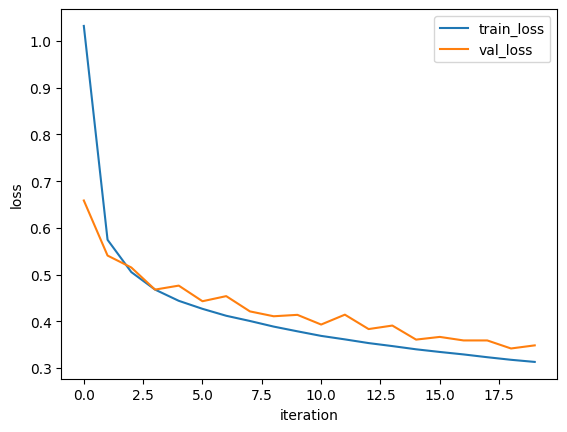

In [21]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 합성곱, ReLU, 풀링
class ConvolutionNetwork:
    def __init__(self, n_kernels=10, units=10, batch_size=32, learning_rate=0.1):
        self.n_kernels = n_kernels # 커널 수
        self.kernel_size = 3 # 커널 크기

        self.optimizer = None

        self.conv_w = None
        self.conv_b = None

        self.units = units # 은닉층 뉴런 갯수
        self.batch_size = batch_size # 배치 크기 

        self.w1 = None # 은닉층 가중치
        self.b1 = None # 은닉층 절편
        self.w2 = None # 출력층 가중치
        self.b2 = None # 출력층 절편
        self.a1 = None # 은닉층 활성화 출력
        self.losses = [] # 훈련 손실
        self.val_losses = [] # 검증 손실
        self.lr = learning_rate # 학습률

    def forpass(self, x):
        c_out = tf.nn.conv2d(x, self.conv_w, strides=1, padding='SAME') + self.conv_b
        r_out = tf.nn.relu(c_out)
        p_out = tf.nn.max_pool2d(r_out, ksize=2, strides=2, padding='VALID')
        f_out = tf.reshape(p_out, [x.shape[0], -1])
        z1 = tf.matmul(f_out, self.w1) + self.b1
        a1 = tf.nn.relu(z1)
        z2 = tf.matmul(a1, self.w2) + self.b2
        return z2

    def init_weights(self, n_features, n_classes):

        g = tf.initializers.glorot_uniform()
        # glorot_uniform 함수
        # : 가중치를 적절하게 초기화해준다.
        self.conv_w = tf.Variable(g((3, 3, 1, self.n_kernels)))
        self.conv_b = tf.Variable(np.zeros(self.n_kernels), dtype=float)
        n_features = 14 * 14 * self.n_kernels

        self.w1 = tf.Variable(g((n_features, self.units)))
        self.b1 = tf.Variable(np.zeros(self.units), dtype=float)

        self.w2 = tf.Variable(g((self.units, n_classes)))
        self.b2 = tf.Variable(np.zeros(n_classes), dtype=float)
    

    def fit(self, x, y, epochs=100, x_val=None, y_val=None):
        self.init_weights(x.shape, y.shape[1])
        self.optimizer = tf.optimizers.SGD(learning_rate=self.lr)
        for i in range(epochs):
            print('에포크', i, end = ' ')
            batch_losses = []
            for x_batch, y_batch in self.gen_batch(x, y):
                print('.', end='')
                self.traning(x_batch, y_batch)
                batch_losses.append(self.get_loss(x_batch, y_batch))
            print()
            self.losses.append(np.mean(batch_losses))
            self.val_losses.append(self.get_loss(x_val, y_val))
    
    def gen_batch(self, x, y):
        bins = len(x) // self.batch_size
        indexes = np.random.permutation(np.arange(len(x)))
        x = x[indexes]
        y = y[indexes]
        for i in range(bins):
            start = self.batch_size * i
            end = self.batch_size * (i+1)
            yield x[start:end], y[start:end]

    def traning(self, x, y):
        with tf.GradientTape() as tape:
            z = self.forpass(x)
            loss = tf.nn.softmax_cross_entropy_with_logits(y, z)
            loss = tf.reduce_mean(loss)
        weights_list = [self.conv_w, self.conv_b, self.w1, self.b1, self.w2, self.b2]
        grads = tape.gradient(loss, weights_list)
        self.optimizer.apply_gradients(zip(grads, weights_list))
       

    def predict(self, x):
        z = self.forpass(x)
        return np.argmax(z, axis=1)
    
    def score(self, x, y):
        return np.mean(self.predict(x) == np.argmax(y, axis=1))

    def get_loss(self, x, y):
        z = self.forpass(x)
        loss = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(y, z))
        return loss.numpy()
    
(x_train_all, y_train_all), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train, x_val, y_train, y_val = train_test_split(x_train_all, y_train_all, stratify=y_train_all, test_size=0.2, random_state=42)


y_train_encoded = tf.keras.utils.to_categorical(y_train)
y_val_encoded = tf.keras.utils.to_categorical(y_val)

x_train = x_train.reshape(-1, 28, 28, 1)
x_val = x_val.reshape(-1, 28, 28, 1)

print(x_train.shape)

x_train = x_train / 255
x_val = x_val / 255

cn = ConvolutionNetwork(n_kernels=10, units=100, batch_size=128, learning_rate=0.01)
cn.fit(x_train, y_train_encoded, x_val=x_val, y_val=y_val_encoded, epochs=20)

plt.plot(cn.losses)
plt.plot(cn.val_losses)
plt.ylabel('loss')
plt.xlabel('iteration')
plt.legend(['train_loss', 'val_loss'])
plt.show()

In [ ]:
# 케라스로 합성곱 신경망 만들기
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

conv1 = tf.keras.Sequential()
conv1.add(Conv2D(10, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)))
conv1.add(MaxPooling2D((2, 2)))
conv1.add(Flatten())
conv1.add(Dense(100, activation='relu'))
conv1.add(Dense(10, activation='softmax'))

conv1.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 10)        100       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 10)       0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 1960)              0         
                                                                 
 dense (Dense)               (None, 100)               196100    
                                                                 
 dense_1 (Dense)             (None, 10)                1010      
                                                                 
Total params: 197,210
Trainable params: 197,210
Non-trainable params: 0
__________________________________________________

In [27]:
# MNIST 필기체 숫자 인식
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

# 필셀 값을 0~1사이로 정규화

train_images, test_images = train_images / 255.0, test_images / 255.0

model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.summary()

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=5)

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_13 (Conv2D)          (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 13, 13, 32)       0         
 2D)                                                             
                                                                 
 conv2d_14 (Conv2D)          (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 5, 5, 64)         0         
 g2D)                                                            
                                                                 
 conv2d_15 (Conv2D)          (None, 3, 3, 64)          36928     
                                                                 
 flatten_5 (Flatten)         (None, 576)              

## 위의 코드의 신경망 구조
<img src="img/zw.png" width="600"/>

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_16 (Conv2D)          (None, 28, 28, 10)        100       
                                                                 
 max_pooling2d_11 (MaxPoolin  (None, 14, 14, 10)       0         
 g2D)                                                            
                                                                 
 flatten_6 (Flatten)         (None, 1960)              0         
                                                                 
 dense_12 (Dense)            (None, 100)               196100    
                                                                 
 dense_13 (Dense)            (None, 10)                1010      
                                                                 
Total params: 197,210
Trainable params: 197,210
Non-trainable params: 0
________________________________________________

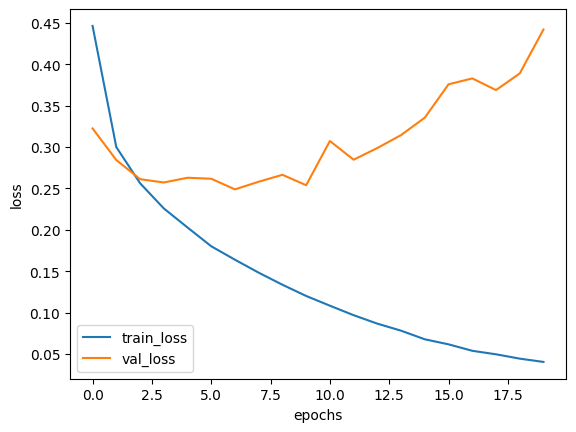

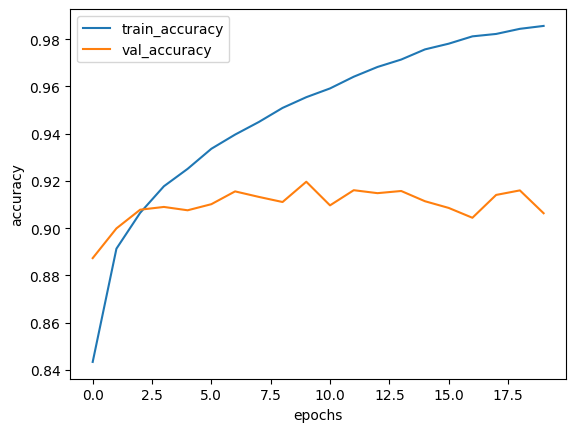

In [28]:
# 케라스로 합성곱 신경망 만들기

from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
import tensorflow as tf

conv1 = tf.keras.Sequential()
conv1.add(Conv2D(10, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)))
conv1.add(MaxPooling2D((2, 2)))

conv1.add(Flatten())

conv1.add(Dense(100, activation='relu'))
conv1.add(Dense(10, activation='softmax'))

conv1.summary()
conv1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

(x_train_all, y_train_all), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train, x_val, y_train, y_val = train_test_split(x_train_all, y_train_all, stratify=y_train_all, test_size=0.2, random_state=42)

y_train_encoded = tf.keras.utils.to_categorical(y_train)
y_val_encoded = tf.keras.utils.to_categorical(y_val)

x_train = x_train.reshape(-1, 28, 28, 1)
x_val = x_val.reshape(-1, 28, 28, 1)

print(x_train.shape)

x_train = x_train / 255
x_val = x_val / 255

history = conv1.fit(x_train, y_train_encoded, epochs=20, validation_data=(x_val, y_val_encoded))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylabel('loss')
plt.xlabel('epochs')
plt.legend(['train_loss', 'val_loss'])
plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.legend(['train_accuracy', 'val_accuracy'])
plt.show()